# Raport Laboratori – Variacioni i kohës së ekzekutimit

**Studenti:** Arteo Carta  
**Data:** 11-06-2026  
**Kursi:** Fizikë & Shkenca Kompjuterike  

---

## Qëllimi i përgjithshëm

Ky raport eksploron dhe mat variacionin natyror të kohës së ekzekutimit të kodit Python. Analizohen faktorët kryesorë që shkaktojnë luhatje si: ngarkesa e CPU-së, menaxhimi i memories, ndërhyrjet e sistemit operativ, overhead-i i interpretuesit Python dhe vonesat nga operacionet I/O.  
Për çdo eksperiment janë dhënë: qëllimi, kodi, rezultatet statistikore dhe interpretimi.


# Eksperimenti 1 – Variacioni natyror i kohës

### Qëllimi
Të vërtetohet eksperimentalisht se koha e ekzekutimit ndryshon mes matjeve, edhe kur kodi dhe inputi janë krejtësisht identike.

T_mean = 0.025247110002674163
T_std  = 0.0029189368173623267
T_min  = 0.022042699856683612
T_max  = 0.04268270009197295
CV     = 0.1156146908320657


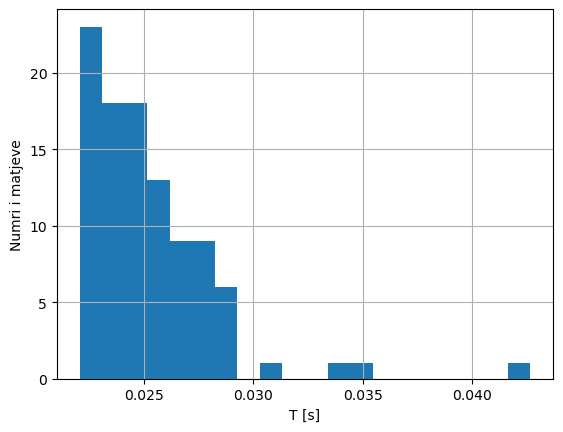

In [1]:
import time, numpy as np, matplotlib.pyplot as plt

M = 80
N = 150_000
times = []

for r in range(M):
    s = 0
    start = time.perf_counter()
    for i in range(N):
        s += i
    end = time.perf_counter()
    times.append(end - start)

times = np.array(times)
print("T_mean =", times.mean())
print("T_std  =", times.std(ddof=1))
print("T_min  =", times.min())
print("T_max  =", times.max())
print("CV     =", times.std(ddof=1)/times.mean())

plt.hist(times, bins=20)
plt.xlabel("T [s]"); plt.ylabel("Numri i matjeve"); plt.grid(True); plt.show()

### Interpretimi
- Histogrami tregon shpërndarje jo identike të kohëve.  
- $T_{std}$ tregon luhatjet rreth mesatares.  
- $CV$ tregon variacionin relativ.  
- Shkaku kryesor janë ndërhyrjet e sistemit operativ dhe cache.

# Eksperimenti 2 – Matje të shkurtra kundrejt atyre të gjata

### Qëllimi
Të demonstrohet se matjet me N të vogël janë shumë më të ndjeshme ndaj zhurmës dhe overhead-it të sistemit krahasuar me ato të gjata.


In [2]:
import time, numpy as np

M = 80
N_values = [100, 500, 1_000, 10_000, 100_000, 1_000_000]

for N in N_values:
    times = []
    for r in range(M):
        s = 0
        start = time.perf_counter()
        for i in range(N):
            s += i
        end = time.perf_counter()
        times.append(end - start)
    times = np.array(times)
    print(N, times.mean(), times.std(ddof=1), times.std(ddof=1)/times.mean())

100 2.2311992943286895e-05 3.2064244935297884e-05 1.4370856524022517
1000 0.0001904210029169917 0.00013935339208133953 0.7318173412944707
10000 0.0012251090072095394 0.00036349487579696155 0.296704108497988
100000 0.012094125014264136 0.0011473642720871296 0.09486955614679833
1000000 0.1270348519925028 0.01405264026457839 0.11062035373889154


### Interpretimi
- Për N të vogla, $CV$ është më i madh sepse overhead-i dominon.  
- Për N të mëdha, matja është më e besueshme.

# Eksperimenti 3 – Python kundrejt NumPy

### Qëllimi
Të krahasohet performanca e një cikli `for` standard në Python me operacionin ekuivalent të vektorizuar në NumPy.


In [3]:
import time, numpy as np

M = 40
N = 800_000
a = np.arange(N)

times_python = []
for r in range(M):
    s = 0
    start = time.perf_counter()
    for i in range(N):
        s += i
    end = time.perf_counter()
    times_python.append(end - start)

times_numpy = []
for r in range(M):
    start = time.perf_counter()
    s = np.sum(a)
    end = time.perf_counter()
    times_numpy.append(end - start)

times_python = np.array(times_python)
times_numpy  = np.array(times_numpy)

print("Python mean/std/CV:", times_python.mean(), times_python.std(ddof=1), times_python.std(ddof=1)/times_python.mean())
print("NumPy  mean/std/CV:", times_numpy.mean(), times_numpy.std(ddof=1), times_numpy.std(ddof=1)/times_numpy.mean())

Python mean/std/CV: 0.1272825259808451 0.011277532095421034 0.0886023592674316
NumPy  mean/std/CV: 0.00039320800453424454 0.0003958449786133579 1.0067063082356038


### Interpretimi
- Python loop ka overhead të madh → kohë më e gjatë.  
- NumPy është i optimizuar → kohë më e shkurtër dhe variacion më i vogël.

# Eksperimenti 4 – Krijimi i të dhënave brenda/jashtë matjes

### Qëllimi
Të shihet ndikimi i krijimit të të dhënave brenda zonës së matur.


In [4]:
import time, numpy as np

M = 40
N = 800_000

times_inside = []
for r in range(M):
    start = time.perf_counter()
    a = np.random.rand(N)
    s = np.sum(a)
    end = time.perf_counter()
    times_inside.append(end - start)

times_outside = []
for r in range(M):
    a = np.random.rand(N)
    start = time.perf_counter()
    s = np.sum(a)
    end = time.perf_counter()
    times_outside.append(end - start)

times_inside = np.array(times_inside)
times_outside = np.array(times_outside)

print("Brenda matjes:", times_inside.mean(), times_inside.std(ddof=1), times_inside.std(ddof=1)/times_inside.mean())
print("Jashtë matjes:", times_outside.mean(), times_outside.std(ddof=1), times_outside.std(ddof=1)/times_outside.mean())

Brenda matjes: 0.023154055983759463 0.06769503082317936 2.9236791545576932
Jashtë matjes: 0.0009603540040552616 0.00013957474116102063 0.14533676183120187


### Interpretimi
- Rasti A (brenda) përfshin edhe kohën e krijimit → më e gjatë.  
- Rasti B (jashtë) mat vetëm llogaritjen → më e shkurtër.

# Eksperimenti 5 – Qasje sekuenciale vs rastësishme

### Qëllimi
Të shihet ndikimi i memories dhe cache.


In [5]:
import time, numpy as np

M = 25
N = 4_000_000
a = np.random.rand(N)
idx = np.random.permutation(N)

times_seq = []
for r in range(M):
    start = time.perf_counter()
    s = np.sum(a)
    end = time.perf_counter()
    times_seq.append(end - start)

times_rand = []
for r in range(M):
    start = time.perf_counter()
    s = np.sum(a[idx])
    end = time.perf_counter()
    times_rand.append(end - start)

times_seq = np.array(times_seq)
times_rand = np.array(times_rand)

print("Sekuenciale:", times_seq.mean(), times_seq.std(ddof=1), times_seq.std(ddof=1)/times_seq.mean())
print("Rastësore:  ", times_rand.mean(), times_rand.std(ddof=1), times_rand.std(ddof=1)/times_rand.mean())

Sekuenciale: 0.003761083330027759 0.0006447356390295161 0.17142285412345742
Rastësore:   0.08550374330176662 0.004683306101893084 0.054773111925221656


### Interpretimi
- Qasja sekuenciale është më e shpejtë → cache dhe prefetching.  
- Qasja e rastësishme prish lokalitetin → më e ngadaltë.

# Eksperimenti 6 – Ndikimi i ngarkesës në sfond

### Qëllimi
Të shihet ndikimi i proceseve të tjera në kohën e ekzekutimit.


In [6]:
import time, numpy as np

M = 40
N = 1_500_000
times = []

for r in range(M):
    s = 0
    start = time.perf_counter()
    for i in range(N):
        s += i * i
    end = time.perf_counter()
    times.append(end - start)

times = np.array(times)
print("T_mean =", times.mean())
print("T_std  =", times.std(ddof=1))
print("CV     =", times.std(ddof=1)/times.mean())

T_mean = 0.3247620719810948
T_std  = 0.014931396445044239
CV     = 0.04597641699340258


### Interpretimi
- Pa ngarkesë → kohë më e qëndrueshme.  
- Me ngarkesë → rritet $T_{mean}$ dhe $CV$.

# Eksperimenti 7 – Ndikimi i printimit dhe I/O

### Qëllimi
Të shihet ndikimi i `print` dhe I/O në matje.


In [8]:
import time, numpy as np

M = 20
N = 8_000

# Pa printim
times_no_print = []
for r in range(M):
    s = 0
    start = time.perf_counter()
    for i in range(N):
        s += i
    end = time.perf_counter()
    times_no_print.append(end - start)

# Me printim të kufizuar
times_with_print = []
for r in range(M):
    s = 0
    start = time.perf_counter()
    for i in range(N):
        s += i
        if i % 1000 == 0:
            print(i)
    end = time.perf_counter()
    times_with_print.append(end - start)

times_no_print = np.array(times_no_print)
times_with_print = np.array(times_with_print)

print("Pa printim:", times_no_print.mean(), times_no_print.std(ddof=1), times_no_print.std(ddof=1)/times_no_print.mean())
print("Me printim:", times_with_print.mean(), times_with_print.std(ddof=1), times_with_print.std(ddof=1)/times_with_print.mean())

0
1000
2000
3000
4000
5000
6000
7000
8000
9000
0
1000
2000
3000
4000
5000
6000
7000
8000
9000
0
1000
2000
3000
4000
5000
6000
7000
8000
9000
0
1000
2000
3000
4000
5000
6000
7000
8000
9000
0
1000
2000
3000
4000
5000
6000
7000
8000
9000
0
1000
2000
3000
4000
5000
6000
7000
8000
9000
0
1000
2000
3000
4000
5000
6000
7000
8000
9000
0
1000
2000
3000
4000
5000
6000
7000
8000
9000
0
1000
2000
3000
4000
5000
6000
7000
8000
9000
0
1000
2000
3000
4000
5000
6000
7000
8000
9000
0
1000
2000
3000
4000
5000
6000
7000
8000
9000
0
1000
2000
3000
4000
5000
6000
7000
8000
9000
0
1000
2000
3000
4000
5000
6000
7000
8000
9000
0
1000
2000
3000
4000
5000
6000
7000
8000
9000
0
1000
2000
3000
4000
5000
6000
7000
8000
9000
0
1000
2000
3000
4000
5000
6000
7000
8000
9000
0
1000
2000
3000
4000
5000
6000
7000
8000
9000
0
1000
2000
3000
4000
5000
6000
7000
8000
9000
0
1000
2000
3000
4000
5000
6000
7000
8000
9000
0
1000
2000
3000
4000
5000
6000
7000
8000
9000
Pa printim: 0.0016389150405302644 0.00046938253307759613 0.2

### Interpretimi
- Printimi brenda loop-it e ngadalëson dukshëm ekzekutimin.  
- I/O nuk duhet përfshirë në matjen e algoritmit, përveç rasteve kur qëllimi është të matet vetë I/O.

# Eksperimenti 8 – Ndryshimi i performancës gjatë një ekzekutimi të gjatë

### Qëllimi
Të shihet nëse koha e ekzekutimit ndryshon gjatë shumë përsëritjeve radhazi për shkak të frekuencës së CPU-së, ngrohjes ose proceseve të sistemit.


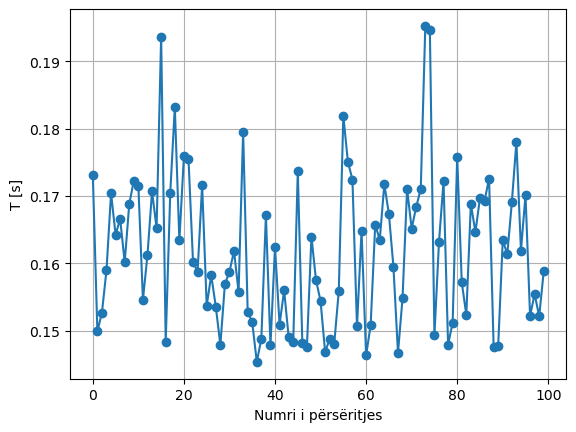

In [9]:
import time, numpy as np, matplotlib.pyplot as plt

M = 80
N = 800_000
times = []

for r in range(M):
    s = 0
    start = time.perf_counter()
    for i in range(N):
        s += i * i
    end = time.perf_counter()
    times.append(end - start)

plt.plot(times, "o-")
plt.xlabel("Numri i përsëritjes")
plt.ylabel("T [s]")
plt.grid(True)
plt.show()

### Interpretimi
- Nëse koha rritet gjatë përsëritjeve → CPU ngrohet ose ul frekuencën.  
- Nëse koha ulet → cache ose optimizime të sistemit.  
- Nëse mbetet konstante → sistemi është stabil.


# Përfundimi

- Koha e ekzekutimit nuk është gjithmonë e njëjtë për shkak të ndërhyrjes së Python-it, CPU-së, memories, OS-it dhe I/O.  
- Eksperimenti me $CV$ më të madh ishte ai me matje shumë të shkurtra (Eksperimenti 2).  
- Overhead-i i Python-it e bën ciklin `for` shumë më të ngadaltë krahasuar me NumPy (Eksperimenti 3).  
- Krijimi i të dhënave brenda matjes e rrit kohën (Eksperimenti 4).  
- Qasja e rastësishme në memorie është më e ngadaltë se ajo sekuenciale (Eksperimenti 5).  
- Ngarkesa në sfond rrit variacionin dhe mesataren e kohës (Eksperimenti 6).  
- Printimi dhe I/O nuk duhet përfshirë në matjen e algoritmit (Eksperimenti 7).  
- Ekzekutimet e gjata mund të tregojnë ndryshime për shkak të CPU-së dhe sistemit (Eksperimenti 8).  

**Ideja kryesore:** Koha e ekzekutimit është një madhësi eksperimentale. Duhet matur disa herë, analizuar statistikisht dhe interpretuar duke marrë parasysh gjuhën e programimit, CPU-në, memorien, sistemin operativ dhe operacionet I/O.
